In [2]:
### Уровень 1 
import pandas as pd
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\train.csv') 
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df["age_category"] = df["Age"].apply(lambda x: "взрослый" if x > 17 else "ребенок")
df
df["счетчик"] = df["Age"].apply(lambda x: 1 if x > 17 else 1) ## не понял по каким критериям можно групприровать пассажиров поэтому сделал так
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_category,счетчик
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,взрослый,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,взрослый,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,взрослый,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,взрослый,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,взрослый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,взрослый,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,взрослый,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,ребенок,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,взрослый,1


In [39]:
a=df['age_category'].value_counts()/len(df)*100
a.loc['ребенок'] ## % детей

np.float64(32.547699214365885)

In [30]:
df['Sex'].value_counts()/len(df)*100 ##% мужчин и женщин

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

In [36]:
## Уровень2
dropped_a = df.dropna(subset=['Age'])##  Посчитать, по скольким людям нет информации (пола или возраста)
dropped_b = df.dropna(subset=['Sex'])
print((len(df))-(len(dropped_a)))
print((len(df))-(len(dropped_b)))

177
0


In [7]:
c=df.groupby('Age')[['счетчик']].sum()
c

,счетчик
Age,
0.42,1
0.67,1
0.75,2
0.83,2
0.92,1
...,...
70.00,2
70.50,1
71.00,2


<Axes: xlabel='Age', ylabel='счетчик'>

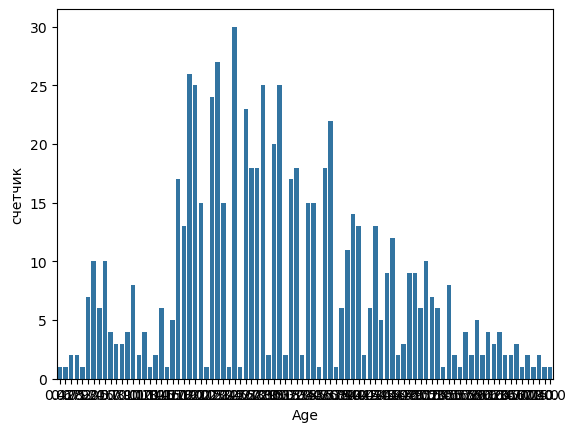

In [8]:
import seaborn as sns
sns.barplot(data=c, x="Age", y="счетчик") ##Вывести гистограмму по возрасту пассажиров

In [30]:
d= df.groupby('Survived')[['Sex']].sum() ##Посчитать, какой процент мужчин и женщин выжили, какой процент детей выжили.
df["Мужчины"] = df["Sex"].apply(lambda x: 1 if x =='male' else 0)## не понял по каким критериям можно групприровать пассажиров поэтому сделал так
df["Женщины"] = df["Sex"].apply(lambda x: 0 if x =='male' else 1)
df["Дети"] = df['age_category'].apply(lambda x: 1 if x =='ребенок' else 0)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_category,счетчик,Дети,Женщины,Мужчины
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,взрослый,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,взрослый,1,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,взрослый,1,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,взрослый,1,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,взрослый,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,взрослый,1,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,взрослый,1,0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,ребенок,1,1,1,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,взрослый,1,0,0,1


In [31]:
d= df.groupby('Survived')[['Мужчины','Женщины','Дети']].sum()
d

,Мужчины,Женщины,Дети
Survived,,,
0,468,81,177
1,109,233,113


In [32]:
d.loc[1,'Дети']/df['Дети'].sum()*100 ## процент выживших детей.

np.float64(38.96551724137931)

In [33]:
d.loc[1,'Мужчины']/df['Мужчины'].sum()*100 ## процент выживших мужчин.

np.float64(18.890814558058924)

In [34]:
d.loc[1,'Женщины']/df['Женщины'].sum()*100 ## процент выживших женщин

np.float64(74.20382165605095)